# Atividades 2, 3 e 4 — Indicadores IBGE (PNAD Contínua e Censo 2022)

Arquivos utilizados:
- `Tabela_1_1_1.xls` — horas semanais em cuidados de pessoas e afazeres domésticos (PNAD Contínua 2022)
- `Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx` — pessoas com graduação por área de formação (Censo)
- `CD2022_Populacao_2010_Compatibilizada_20231222.xlsx` — população por município (Censo 2022)

In [1]:
pip install matplotlib seaborn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")

## Atividade 2 (horas que mulheres trabalham em serviços domésticos)

Fonte: **Tabela 1.1.1** — número médio de horas semanais dedicadas aos cuidados
de pessoas e/ou afazeres domésticos, por sexo e cor ou raça, segundo Grandes Regiões.

In [3]:
# Leitura da Tabela 1.1.1 (aba "2022") e organização em um DataFrame limpo
raw1 = pd.read_excel(
    "/mnt/user-data/uploads/Tabela_1_1_1.xls",
    sheet_name="2022", engine="xlrd", header=None
)

# As linhas 8 a 40 (índice) contêm Brasil, as 5 Grandes Regiões e as 27 UFs
data1 = raw1.iloc[8:41].reset_index(drop=True)
data1.columns = [
    "uf_regiao", "total", "total_branca", "total_preta_parda",
    "homem_branca", "homem_preta_parda", "mulher_branca", "mulher_preta_parda",
]
num_cols = data1.columns.drop("uf_regiao")
data1[num_cols] = data1[num_cols].apply(pd.to_numeric, errors="coerce")

indicador_1 = data1.dropna(subset=["uf_regiao"]).reset_index(drop=True)
indicador_1.head()

,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Brasil,16.985781,16.545930,17.333142,11.705136,11.746330,20.404106,22.037998
1,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986


In [4]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

# Barras agrupadas: homens x mulheres por grande região
reg = indicador_1[indicador_1["uf_regiao"].isin(regioes)].copy()
reg["homens"] = (reg["homem_branca"] + reg["homem_preta_parda"]) / 2
reg["mulheres"] = (reg["mulher_branca"] + reg["mulher_preta_parda"]) / 2

reg_long = reg.melt(
    id_vars="uf_regiao",
    value_vars=["homens", "mulheres"],
    var_name="sexo",
    value_name="horas",
)
reg_long

,uf_regiao,sexo,horas
0,Norte,homens,11.551649
1,Nordeste,homens,11.786171
2,Sudeste,homens,12.057182
3,Sul,homens,11.353058
4,Centro-Oeste,homens,10.439429
5,Norte,mulheres,19.914984
6,Nordeste,mulheres,23.230691
7,Sudeste,mulheres,21.361700
8,Sul,mulheres,19.175851
9,Centro-Oeste,mulheres,18.775862


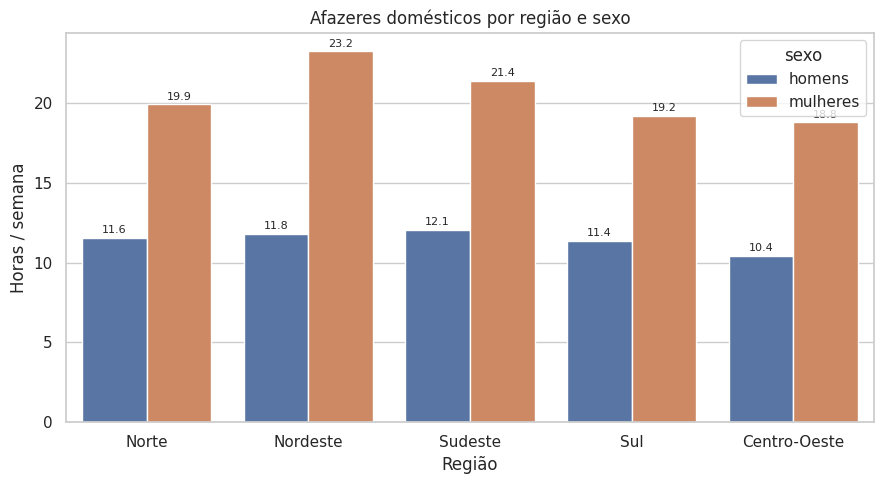

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=reg_long, x="uf_regiao", y="horas", hue="sexo", ax=ax)
ax.set_title("Afazeres domésticos por região e sexo")
ax.set_xlabel("Região")
ax.set_ylabel("Horas / semana")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f", padding=2, fontsize=8)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** em todas as Grandes Regiões as mulheres dedicam
quase o dobro de horas semanais aos afazeres domésticos em relação aos homens,
sendo a diferença maior no Nordeste (≈ 23,2h x 11,8h) e menor no Centro-Oeste
(≈ 18,8h x 10,4h).

## Atividade 3 (formação acadêmica)

Fonte: **Tabela 3** — pessoas com graduação concluída, por área geral de formação e sexo.

- **Total** → formação total (todas as áreas)
- **STEM** → "Ciência, Tecnologia, Engenharias e Matemática"
- **Saúde/educação** → "Educação, Serviços pessoais, Saúde e Bem-estar"

In [6]:
# Leitura da Tabela 3 e organização em três DataFrames (total, STEM, saúde/educação)
raw2 = pd.read_excel(
    "/mnt/user-data/uploads/Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx",
    sheet_name="Sheet1", header=None
)

data2 = raw2.iloc[3:36].reset_index(drop=True)
data2.columns = [
    "uf_regiao", "total_geral", "total_homens", "total_mulheres",
    "stem_total", "stem_homens", "stem_mulheres",
    "saude_total", "saude_homens", "saude_mulheres",
]
num_cols2 = data2.columns.drop("uf_regiao")
data2[num_cols2] = data2[num_cols2].apply(pd.to_numeric, errors="coerce")

formacao_total = data2[["uf_regiao", "total_geral", "total_homens", "total_mulheres"]].copy()

formacao_stem = data2[["uf_regiao", "stem_total", "stem_homens", "stem_mulheres"]].copy()
formacao_stem.columns = ["uf_regiao", "total", "homens", "mulheres"]

formacao_saude = data2[["uf_regiao", "saude_total", "saude_homens", "saude_mulheres"]].copy()
formacao_saude.columns = ["uf_regiao", "total", "homens", "mulheres"]

formacao_total.head()

,uf_regiao,total_geral,total_homens,total_mulheres
0,Brasil,25854291,10478534,15375757
1,Norte,1525166,590558,934609
2,Nordeste,4748933,1744994,3003939
3,Sudeste,12828829,5391638,7437191
4,Sul,4338861,1768855,2570005


In [7]:
# Barras agrupadas: homens x mulheres no Brasil (três recortes)
brasil = pd.DataFrame(
    {
        "area": ["Graduação (total)", "STEM", "Saúde / educação"],
        "homens": [
            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_homens"].item(),
            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "homens"].item(),
            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "homens"].item(),
        ],
        "mulheres": [
            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_mulheres"].item(),
            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "mulheres"].item(),
            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "mulheres"].item(),
        ],
    }
)
brasil_long = brasil.melt(id_vars="area", var_name="sexo", value_name="pessoas")
brasil_long

,area,sexo,pessoas
0,Graduação (total),homens,10478534
1,STEM,homens,2750422
2,Saúde / educação,homens,1677985
3,Graduação (total),mulheres,15375757
4,STEM,mulheres,1398619
5,Saúde / educação,mulheres,6401723


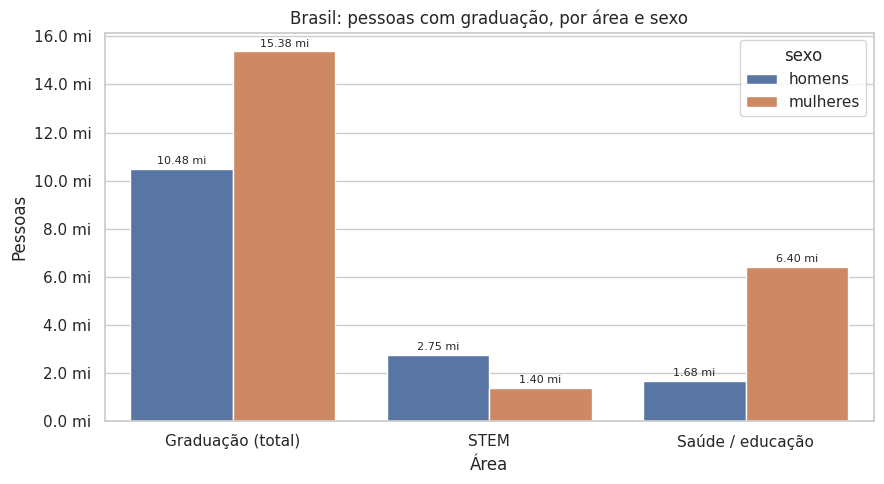

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)
ax.set_title("Brasil: pessoas com graduação, por área e sexo")
ax.set_xlabel("Área")
ax.set_ylabel("Pessoas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f} mi"))
for cont in ax.containers:
    ax.bar_label(cont, fmt=lambda v: f"{v/1e6:.2f} mi", padding=2, fontsize=8)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** mulheres são maioria entre graduados no total
(15,4 milhões x 10,5 milhões) e amplamente maioria em Saúde/educação
(6,4 milhões x 1,7 milhão). O padrão se inverte em STEM, onde os homens
são maioria (2,75 milhões x 1,40 milhão).

## Atividade 4 (população 2022 por UF)

Fonte: **Censo Demográfico 2022** — população recenseada por município,
agregada aqui por Unidade da Federação.

In [9]:
# Leitura da planilha de municípios e agregação da população 2022 por UF
raw3 = pd.read_excel(
    "/mnt/user-data/uploads/CD2022_Populacao_2010_Compatibilizada_20231222.xlsx",
    sheet_name="Municípios", header=None
)

data3 = raw3.iloc[3:5573, 1:8].reset_index(drop=True)
data3.columns = ["UF", "cod_uf", "cod_munic", "municipio",
                  "pop2010_sinopse", "pop2010_compat", "pop2022"]
data3 = data3.dropna(subset=["UF"])
data3["pop2022"] = pd.to_numeric(data3["pop2022"], errors="coerce")

pop_estado = data3.groupby("UF", as_index=False)["pop2022"].sum()
pop_estado = pop_estado.rename(columns={"pop2022": "2022"})
pop_estado.head()

,UF,2022
0,AC,830018
1,AL,3127683
2,AM,3941613
3,AP,733759
4,BA,14141626


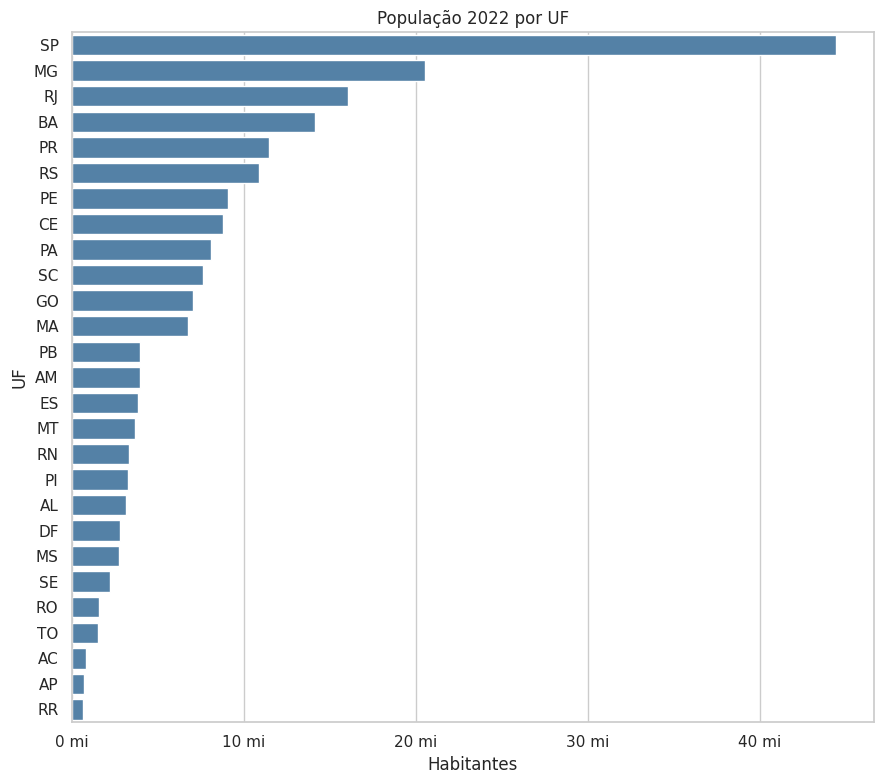

In [10]:
# Barras: população 2022 por UF
fig, ax = plt.subplots(figsize=(9, 8))
ordem = pop_estado.sort_values("2022", ascending=False)
sns.barplot(data=ordem, y="UF", x="2022", ax=ax, color="steelblue")
ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f} mi"))
plt.tight_layout()
plt.show()

**Leitura do gráfico:** São Paulo concentra, isoladamente, a maior
população do país (≈ 44,4 milhões), seguida por Minas Gerais (≈ 20,5 milhões)
e Rio de Janeiro (≈ 16,1 milhões). Roraima, Amapá e Acre são as UFs menos
populosas, todas abaixo de 1 milhão de habitantes.

## Atualização da atividade no GIT

Depois de rodar e conferir as três atividades neste notebook, finalize a
entrega atualizando o repositório no GitHub:

```bash
git add .
git commit -m "Atividades 2, 3 e 4: gráficos de afazeres domésticos, formação acadêmica e população 2022"
git push origin main
```

> Este passo precisa ser executado no seu ambiente local/Colab, com o seu
> repositório já clonado e autenticado — não tenho acesso ao seu repositório
> Git para fazer o commit/push por você.